# 1. Load the NACC Dataset

In [1]:
#import some needed library
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_selection import VarianceThreshold
from sklearn.model_selection import train_test_split
from imblearn.combine import SMOTETomek
from sklearn.preprocessing import MinMaxScaler

from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
#import and load dataset
nacc = pd.read_csv('investigator_nacc71.csv')
nacc.head(10)

C:\Users\User\AppData\Local\Temp\ipykernel_34596\3286337486.py:2: DtypeWarning: Columns (20,22,24,26,28,41,44,46,48,51,61,63,65,67,69,71,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,134,156,165,176,179,189,217,220,222,224,226,228,230,232,234,236,238,240,242,244,246,248,250,252,254,256,258,260,262,264,266,268,270,272,382,397,399,401,419,421,423,432,445,454,494,574,605,613,638,674,690,704,707,710,715,727,738,744,746,804,809,810,811,812,820,831,833,835,837,843,904,959,960,961,969,970,971,972,982,1004,1007,1010) have mixed types. Specify dtype option on import or set low_memory=False.
  nacc = pd.read_csv('investigator_nacc71.csv')


,NACCID,NACCADC,PACKET,FORMVER,VISITMO,VISITDAY,VISITYR,NACCVNUM,NACCAVST,NACCNVST,...,NPATGAM1,NPATGAM2,NPATGAM3,NPATGAM4,NPATGAM5,NPATGFRN,NPATGFR1,NPATGFR2,NPATGFR3,NPATGFR4
0,NACC002909,186,I,3.0,12,28,2022,1,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
1,NACC002909,186,F,3.0,1,23,2024,2,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
2,NACC002909,186,F,3.0,3,5,2025,3,3,3,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
3,NACC003142,186,I,3.0,2,11,2025,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
4,NACC003487,186,I,3.0,11,15,2023,1,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
5,NACC003487,186,F,3.0,1,15,2025,2,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
6,NACC004352,186,I,3.0,10,5,2021,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
7,NACC004687,186,I,3.0,11,14,2022,1,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
8,NACC004687,186,F,3.0,9,4,2024,2,2,2,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4
9,NACC004848,186,I,3.0,11,8,2024,1,1,1,...,-4,-4,-4,-4,-4,-4,-4,-4,-4,-4


In [3]:
#get basic info of dataset
nacc.shape

(205908, 1024)

In [4]:
#get basic info of dataset
nacc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205908 entries, 0 to 205907
Columns: 1024 entries, NACCID to NPATGFR4
dtypes: float64(135), int64(747), object(142)
memory usage: 1.6+ GB


# 2. Basic Data Preprocessing

## a. Visit Selection

In [5]:
#filter the dataset only keep the baselind visit for each subject
nacc_baseline = nacc[nacc['NACCVNUM'] == 1].copy()
print(f"Shape after Visit Selection:", nacc_baseline.shape)

Shape after Visit Selection: (55004, 1024)


## b. Manual Filtering

In [6]:
#remove ID, visit, date, copartcipant data, milestone, neuropathology features & others
#*REFER to uds3-rdd.pdf
coltodrop = ['NACCID', 'NACCAGEB', 'NACCADC', 'PACKET', 'FORMVER', 'NACCVNUM', 'VISITMO', 'VISITYR', #id, form header, visit dates
             'VISITDAY','NACCAVST', 'NACCNVST', 'NACCDAYS', 'NACCFDYS', 'NACCREAS','NACCREFR', #form header, visit dates
             'BIRTHMO', 'BIRTHYR', 'INBIRMO', 'INBIRYR', 'INSEX', 'INHISP', 'INHISPOR', 'INRACE', 'INRASEC', #coparticipant data
             'INRATER', 'INEDUC', 'INRELTO', 'INKNOWN', 'INLIVWTH', 'INVISITS', 'INCALLS', 'INRELY', 'NACCNINR',  #coparticipant data
             'NACCACTV', 'NACCNOVS', 'NACCDSMO', 'NACCDSDY', 'NACCDSYR', 'NACCNURP', 'NACCNRMO', #milestones
             'NACCNRDY', 'NACCNRYR', 'NACCMDSS', 'NACCPAFF', 'NACCLIVS', 'NORMEXAM', 'INDEPEND', 'HISPANIC'] 

#remove neuropathology colomun by searching variable name start with NP
neurodrop = [c for c in nacc_baseline.columns if c.startswith('NP')]
#remove the rest neuropathology variables
#*REFER to rdd-np.pdf
neurodrop2 = ['NACCADC', 'NACCDAGE', 'NACCMOD', 'NACCDIED', 'NACCYOD', 'NACCINT',
              'NACCBRNN', 'NACCAVAS', 'NACCBRAA', 'NACCNEUR', 'NACCDIFF',
              'NACCVASC', 'NACCAMY', 'NACCINF', 'NACCMICR', 'NACCHEM',
              'NACCARTE', 'NACCNEC', 'NACCLEWY', 'NACCPICK', 'NACCCBD',
              'NACCPROG', 'NACCPRIO', 'NACCDOWN', 'NACCOTHP', 'NACCWRI1',
              'NACCWRI2', 'NACCWRI3', 'NACCBNKF', 'NACCFORM', 'NACCPARA',
              'NACCCSFP']

#post-diagnosis variables that not needed
target_leakage_var = ['DEMENTED', 'NACCNORM', 'NACCMCII', 'NACCIDEM', 'NACCNREX', 
                      'COGSTAT', 'NORMCOG', 'COGOTH', 'APA', 'OTHCOG', 'NACCNMRI',
                      'COGJUDG', 'AGIT', 'CVD', 'IRR', 'NACCAPOE', 'DXMETHOD', 'NACCMRSA']

clinical_judge_var = ['B9CHG', 'DECSUB', 'DECIN', 'DECCLIN', 'DECCLCOG', 'COGMEM',
                      'COGORI', 'COGLANG', 'COGVIS', 'COGATTN', 'COGFLUC', 'COGFLAGO',
                      'COGOTHR', 'COGOTHRX', 'NACCCOGF', 'NACCCGFX', 'COGMODE', 'COGMODEX',
                      'DECAGE', 'DECCLBE', 'BEAPATHY', 'BEDEP', 'BEVHALL', 'BEVWELL', 'BEVHAGO',
                      'BEAHALL', 'BEDEL', 'BEDISIN', 'BEIRRIT', 'BEAGIT', 'BEPERCH', 'BEREM',
                      'BEREMAGO', 'BEANX', 'BEOTHR', 'BEOTHRX', 'NACCBEHF', 'NACCBEFX', 
                      'BEMODE', 'BEMODEX', 'BEAGE', 'DECCLMOT', 'MOGAIT', 'MOFALLS',
                      'NACCMOTF', 'MOMODE', 'MOMODEX', 'MOMOPARK', 'PARKAGE', 'MOMOALS',
                      'ALSAGE', 'MOAGE', 'COURSE', 'FRSTCHG', 'LBDEVAL', 'FTLDEVAL']

#medical record crash with clinical diagnosis or not clinical that affect
med_his = ['HYPERTEN', 'ARTHRIT', 'ARTH', 'ARTHSPIN', 'ARTHUPEX', 'ARTHLOEX', 'HYPERCHO', 
           'DIABETES', 'BPSYS', 'BPDIAS', 'DIABTYPE', 'HRATE', 'TOBAC100', 'HYPCHOL', 'DEP2YRS',
           'AFIBRILL', 'CONGHRT', 'STROKE', 'DEP', 'HEIGHT', 'WEIGHT', 'ALCOCCAS', 'TOBAC30',
           'OTHCOND', 'OTHCONDX', 'OTHNEUR', 'OTHNEURX', 'APNEA', 'SLEEPAP', 'HEARING', 'HEARAID',
           'HEARWAID', 'VISCORR', 'VISWCORR', 'DEPOTHR', 'DEPIF', 'DEPTREAT', 'THYROID', 'VISION',
           'DEPOTHR', 'CANCER', 'THYDIS', 'URINEINC', 'INCONTU', 'HANDED', 'HYPOSOM', 'NACCMOM', 
           'NACCFAM', 'NACCDAD', 'INSOMN', 'TBI', 'CVOTHR', 'B12DEF', 'PACKSPER']

#other genetic variables
gen_var = ['ADGCGWAS', 'ADGCEXOM', 'ADGCRND', 'ADGCEXR', 'NGDSGWAS', 'NGDSEXOM',
           'NGDSWGS', 'NGDSWES', 'NGDSGWAC', 'NGDSEXAC', 'NGDSWGAC', 'NACCNCRD']

#medication variable 
med_var = ['NACCAMD', 'NACCAC', 'NACCAPSY', 'NACCADEP', 'NACCAHTN', 'NACCHTNC',
           'NACCACEI', 'NACCAAAS', 'NACCBETA', 'NACCCCBS', 'NACCDIUR', 'NACCVASD',
           'NACCANGI', 'NACCLIPL', 'NACCNSD', 'NACCAC', 'NACCADEP', 'NACCAPSY',
           'NACCAANX', 'NACCADMD', 'NACCPDMD', 'NACCEMD', 'NACCEPMD', 'NACCDBMD']

coltodrop.extend(neurodrop)
coltodrop.extend(neurodrop2)
coltodrop.extend(target_leakage_var)
coltodrop.extend(clinical_judge_var)
coltodrop.extend(med_his)
coltodrop.extend(gen_var)
coltodrop.extend(med_var)


nacc_new = nacc_baseline.drop(columns=coltodrop)
print(f"Total columns to drop: {len(coltodrop)}")
print(f"Shape after Manual Filtering:", nacc_new.shape)

Total columns to drop: 430
Shape after Manual Filtering: (55004, 599)


In [7]:
# Drop MMSE Features (Keep MoCA) *MoCA is sensitive than MMSE
mmse_cols = [c for c in nacc_new.columns if 'MMSE' in c]
mmse_cols.extend(['PENTAGON'])

#Drop MoCA subvariables to keep only the Total Score, NACCMOCA
moca_subs = [c for c in nacc_new.columns if c.startswith('MOCA')]

#Drop CDR subvarible to keep only total, CDRSUM
cdr_subs = ['MEMORY', 'ORIENT', 'JUDGMENT', 'COMMUN', 'HOMEHOBB', 'PERSCARE', 
            'CDRGLOB', 'COMPORT', 'CDRLANG']

#drop gds sub score to keep total only, NACCGDS
gds_subs = ['NOGDS', 'SATIS', 'DROPACT', 'EMPTY', 'BORED', 'SPIRITS', 'AFRAID',
            'HAPPY', 'HELPLESS', 'STAYHOME', 'MEMPROB', 'WONDRFUL', 'WRTHLESS',
            'ENERGY', 'HOPELESS', 'BETTER']

#too many Neuropsychological tests taking more time and some tests test the same function 
#so only keep important test (Trail A and B) that are not overlap 
other_test = ['TRAILARR', 'TRAILALI', 'TRAILBRR', 'TRAILBLI', 'CRAFTDRE', 'CRAFTDVR',
             'ANIMALS', 'VEG', 'CRAFTVRS', 'CRAFTURS', 'UDSBENTC', 'UDSBENRS', 'UDSBENTD',
             'UDSVERFC', 'UDSVERFN', 'UDSVERNF', 'UDSVERLC', 'UDSVERLR', 'UDSVERLN',
             'UDSVERTN', 'UDSVERTE', 'UDSVERTI', 'DIGFORCT', 'DIGFORSL', 'DIGBACCT',
             'DIGIF', 'DIGIFLEN', 'DIGIB', 'DIGIBLEN', 'DIGBACLS', 'MINTTOTW', 'MINTSCNG',
             'MINTSCNC', 'MINTPCNG', 'MINTPCNC', 'CRAFTCUE', 'CRAFTDTI']

#other diagnosis variables  
other_var = ['DYSILL', 'FTLDNOS', 'BRNINJ', 'PARKSIGN', 'MOSLOW',  
             'STOVE', 'DIGFORSL', 'DIGBACLS', 'DIGBACCT']
#npiq variable
npiq_vars = ['DEL', 'HALL', 'AGIT', 'DEPD', 'ANX', 'ELAT', 'APA', 'DISN', 'IRR', 
             'MOT', 'NITE', 'APP']

total_drop = mmse_cols + moca_subs + cdr_subs + gds_subs + other_test + other_var
nacc_new2 = nacc_new.drop(columns=total_drop)
nacc_new2 = nacc_new2.drop(columns=[c for c in nacc_new.columns if any(p in c for p in npiq_vars)], errors='ignore')

print(f"New Shape after filtering: {nacc_new2.shape}")

New Shape after filtering: (55004, 457)


In [8]:
#Regroup the target variable NACCUDSD
#Drop code 2 Impaired-Not-MCI cuz it is inconsistently defined and heterogeneous
# not quite normal and not quite MCI so remove it to make it cleaner
nacc_new3 = nacc_new2[nacc_new2['NACCUDSD'] != 2].copy()

#filter dementia, only keep Alzheimer's Disease Dementia (project focus)
#use NACCALZD to keep AD dementia from NACCUDSD
#keep 3 classes including AD dementia
three_classes = (nacc_new3['NACCUDSD'].isin([1, 3])) | ((nacc_new3['NACCUDSD'] == 4) & (nacc_new3['NACCALZD'] == 1))
nacc_new3 = nacc_new3[three_classes].copy()

#Drop the NACCALZD column
nacc_new4 = nacc_new3.drop(columns=['NACCALZD'])

print(f"New Shape: {nacc_new4.shape}")
print(f"Class Counts:\n{nacc_new4['NACCUDSD'].value_counts().sort_index()}")

New Shape: (48529, 456)
Class Counts:
NACCUDSD
1    22760
3    12360
4    13409
Name: count, dtype: int64


## c. Data Cleaning

In [9]:
# In NACC, missing values are shown as -4, replace with nan
nacc_clean = nacc_new3.replace(-4, np.nan)

#there are more codes mean unknown, not applicable like 8, 9, 88, 99, 888, 999, 8888, 9999
#replace with nan
trash_code_b = [88, 99, 888, 999, 8888, 9999, 88.8, 888.8]
trash_code_s = [8, 9]

#trail a and b have problem code 995-998, change to nan
if 'TRAILB' in nacc_clean.columns:
    nacc_clean['TRAILB'] = nacc_clean['TRAILB'].replace([995, 996, 997, 998], np.nan)

if 'TRAILA' in nacc_clean.columns:
    nacc_clean['TRAILA'] = nacc_clean['TRAILA'].replace([995, 996, 997, 998], np.nan)

#mint has 95-98 problem code, change to nan
if 'MINTTOTS' in nacc_clean.columns:
    nacc_clean['MINTTOTS'] = nacc_clean['MINTTOTS'].replace([95, 96, 97, 98], np.nan)


#variables that need careful clean because score range overlap with missing code
critical_var = ['NACCMOCA', 'NACCGDS', 'CDRSUM', 'EDUC', 'NACCUDSD', 'SMOKYRS']
critical_exist = [c for c in critical_var if c in nacc_clean.columns]
trail_var = ['TRAILA', 'TRAILB']
problem_s_var = ['MINTTOTS']

#other category col (category feature normally dont have more than 10 categories)
other_cols = set(trail_var + problem_s_var + critical_exist + ['NACCAGE'])
general_cols = [c for c in nacc_clean.columns if c not in other_cols]
cat_cols = [col for col in general_cols 
            if nacc_clean[col].nunique(dropna=True) <= 10]


#clean
nacc_clean[general_cols] = nacc_clean[general_cols].replace(trash_code_b, np.nan)
nacc_clean[critical_exist] = nacc_clean[critical_exist].replace(trash_code_b, np.nan)
nacc_clean[cat_cols] = nacc_clean[cat_cols].replace(trash_code_s, np.nan)

#check total missing values
print(f"Total Missing Values: {nacc_clean.isnull().sum().sum()}")

C:\Users\User\AppData\Local\Temp\ipykernel_34596\3425142555.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  nacc_clean = nacc_new3.replace(-4, np.nan)


Total Missing Values: 14521317


In [10]:
#MoCA has many missing parts because it was only adopted since 2015
#check whether important variable NACCMoCA has how many percentage missing
#if more than 50% missing, cannot do imputation, remove missing rows instead
total_subject = len(nacc_clean)
moca_missing = nacc_clean['NACCMOCA'].isna().sum()
moca_missingpercent = (moca_missing / total_subject) * 100
print(f"MoCA Missing Percentage: {moca_missingpercent:.2f}%")

MoCA Missing Percentage: 62.40%


In [11]:
#since important variable NACCMoCA has more than 50% missing, cannot impute
#only can remove missing rows
nacc_clean1 = nacc_clean.copy()
nacc_clean1 = nacc_clean1.dropna(subset=['NACCMOCA'])
miss_percent = nacc_clean1.isnull().sum() / len(nacc_clean1) * 100
cols_more50miss = miss_percent[miss_percent > 50].index
nacc_clean2 = nacc_clean1.drop(columns=cols_more50miss)

print(f"Final Subject: {nacc_clean2.shape[0]}")
print(f"Number of Features Left: {nacc_clean2.shape[1]}")
print(f"Total Missing Values Left: {nacc_clean2.isnull().sum().sum()}")

Final Subject: 18245
Number of Features Left: 155
Total Missing Values Left: 105281


In [12]:
nacc_clean2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 18245 entries, 0 to 205907
Columns: 155 entries, NACCCORE to NACCNE4S
dtypes: float64(123), int64(25), object(7)
memory usage: 21.7+ MB


In [13]:
#there are object type variables
#check the rest object whether it is important or not
object_cols = nacc_clean2.select_dtypes(include=['object']).columns.tolist()
print(f"The object columns are: {object_cols}")

The object columns are: ['DRUG1', 'DRUG2', 'DRUG3', 'DRUG4', 'DRUG5', 'DRUG6', 'NGDSWEAC']


In [14]:
#clean all obj variables (not clinical predictors)
nacc_cleaned = nacc_clean2.drop(columns=object_cols)

print(f"New Shape: {nacc_cleaned.shape}")

New Shape: (18245, 148)


In [15]:
#Imputation for nan values
con_var = ['NACCAGE', 'EDUC', 'NACCMOCA', 'CDRSUM', 'NACCGDS', 'MINTTOTS',
            'TRAILA', 'TRAILB', 'SMOKYRS'] #influential continuous var
cat_var = [c for c in nacc_cleaned.columns if c not in con_var] #categorical var
#continuous nan replaced by median, categorical nan replaced by mode
nacc_cleaned[con_var] = nacc_cleaned[con_var].fillna(nacc_cleaned[con_var].median())
nacc_cleaned[cat_var] = nacc_cleaned[cat_var].fillna(nacc_cleaned[cat_var].mode().iloc[0])

print("~ Final Cleaning Results ~")
print(f"Total missing values: {nacc_cleaned.isnull().sum().sum()}") #must 0
print(f"Final Shape: {nacc_cleaned.shape}")

~ Final Cleaning Results ~
Total missing values: 0
Final Shape: (18245, 148)


## d. Encoding

In [16]:
#For target variable NACCUDSD, rename to target (easy to read)
# Mapping: 1 to 0 (Normal), 3 to 1 (MCI), 4 to 2 (AD Dementia)
target_map = {1: 0, 3: 1, 4: 2}
nacc_cleaned['Target'] = nacc_cleaned['NACCUDSD'].map(target_map)
#drop original NACCUDSD column
nacc_cleaned = nacc_cleaned.drop(columns=['NACCUDSD'])

print(f"Target Distribution:\n{nacc_cleaned['Target'].value_counts().sort_index()}")

Target Distribution:
Target
0    9825
1    5146
2    3274
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_26952\2770219835.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  nacc_cleaned['Target'] = nacc_cleaned['NACCUDSD'].map(target_map)


In [17]:
#for categorical variables: one-hot encoding except continuous data
nacc_encode = nacc_cleaned.copy()
continuous_var = ['NACCAGE', 'EDUC', 'NACCBMI', 'NACCMOCA', 'CDRSUM', 'NACCGDS', 
                  'MINTTOTS', 'TRAILA', 'TRAILB', 'SMOKYRS']
continuous_var = [c for c in continuous_var if c in nacc_encode.columns]
encode_col = [c for c in nacc_encode.columns if c not in continuous_var + ['Target']]
#encode 
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(nacc_encode[encode_col])
encoded_feature_names = ohe.get_feature_names_out(encode_col)
#create a DataFrame with encoded variables
encoded_df = pd.DataFrame(encoded_array, columns=encoded_feature_names, index=nacc_encode.index)
nacc_ml = pd.concat([nacc_encode[continuous_var], encoded_df, nacc_encode[['Target']]], axis=1)

print(f"Features after encoding: {nacc_ml.shape[1]}")

Features after encoding: 212


# Exploratory Data Analysis (EDA)

## a. Descriptive Statistics

In [18]:
#Check distribution of target variable NACCUDSD
count = nacc_ml['Target'].value_counts()
percentage = nacc_ml['Target'].value_counts(normalize=True) * 100

#make a table
distribution = pd.DataFrame({'Count': count, 'Percentage': percentage.map('{:.4f}%'.format)})
distribution = distribution.sort_index() #the index is not arranged, need sort

#map index to names
names = {0: 'Normal Cognition', 1: 'MCI', 2: 'AD Dementia'}
distribution.index = distribution.index.map(names)

print("~ Target Variable Distribution ~")
display(distribution)

~ Target Variable Distribution ~


,Count,Percentage
Target,,
Normal Cognition,9825,53.8504%
MCI,5146,28.2050%
AD Dementia,3274,17.9446%


In [19]:
#select cleaned numerical variables to describe because too many variables
#so just describe the important one
spec_cols = ['NACCAGE', 'EDUC', 'NACCMOCA', 'CDRSUM', 'NACCGDS', 'MINTTOTS',
            'TRAILA', 'TRAILB', 'SMOKYRS']
#then filter list to only columns that exist
existing_spec_cols = [c for c in spec_cols if c in nacc_ml.columns]
display(nacc_ml[existing_spec_cols].describe().round(4))

,NACCAGE,EDUC,NACCMOCA,CDRSUM,NACCGDS,MINTTOTS,TRAILA,TRAILB,SMOKYRS
count,18245.0000,18245.0000,18245.0000,18245.0000,18245.0000,18245.0000,18245.0000,18245.0000,18245.0000
mean,69.3046,15.8977,22.9781,1.3759,1.9304,28.4009,41.5064,110.5182,6.6398
std,9.9115,2.9736,5.6418,2.3454,2.3759,4.2518,26.4184,69.2301,12.4936
min,18.0000,0.0000,0.0000,0.0000,0.0000,0.0000,8.0000,8.0000,0.0000
25%,64.0000,14.0000,20.0000,0.0000,0.0000,27.0000,26.0000,66.0000,0.0000
50%,70.0000,16.0000,24.0000,0.5000,1.0000,30.0000,34.0000,88.0000,0.0000
75%,76.0000,18.0000,27.0000,2.0000,3.0000,31.0000,46.0000,124.0000,9.0000
max,103.0000,31.0000,30.0000,18.0000,15.0000,32.0000,150.0000,300.0000,80.0000


In [20]:
#for detail univariate analysis
#this function is from data mining subject lab2, add Skewness, Kurtosis, Variance, Std Dev
def Univariate(dataset, quan):
    # Create a DataFrame with the specified index and columns
    descriptive = pd.DataFrame(index=[
        "Mean", "Median", "Mode", "Q1:25%", "Q2:50%", "Q3:75%", "Q4:100%",
        "IQR", "1.5rule", "Lesser", "Greater", "Min", "Max", "Skewness", "Kurtosis",
        "Variance", "Std Dev"
    ], columns=quan)

    # Loop through each quantitative column and calculate the statistics
    for columnName in quan:
        descriptive.loc["Mean", columnName] = round(nacc_ml[columnName].mean(), 1)
        descriptive.loc["Median", columnName] = round(nacc_ml[columnName].median(), 1)
        descriptive.loc["Mode", columnName] = round(nacc_ml[columnName].mode()[0], 1)
        descriptive.loc["Q1:25%", columnName] = round(nacc_ml[columnName].quantile(0.25), 1)
        descriptive.loc["Q2:50%", columnName] = round(nacc_ml[columnName].quantile(0.50), 1)  # same as median
        descriptive.loc["Q3:75%", columnName] = round(nacc_ml[columnName].quantile(0.75), 1)
        descriptive.loc["Q4:100%", columnName] = round(nacc_ml[columnName].max(), 1)
        descriptive.loc["IQR", columnName] = round(descriptive.loc["Q3:75%", columnName] - descriptive.loc["Q1:25%", columnName], 1)
        descriptive.loc["1.5rule", columnName] = round(1.5 * descriptive.loc["IQR", columnName], 1)
        descriptive.loc["Lesser", columnName] = round(descriptive.loc["Q1:25%", columnName] - descriptive.loc["1.5rule", columnName], 1)
        descriptive.loc["Greater", columnName] = round(descriptive.loc["Q3:75%", columnName] + descriptive.loc["1.5rule", columnName], 1)
        descriptive.loc["Min", columnName] = round(nacc_ml[columnName].min(), 1)
        descriptive.loc["Max", columnName] = round(nacc_ml[columnName].max(), 1)
        descriptive.loc["Skewness", columnName] = round(nacc_ml[columnName].skew(), 1)  # Add Skewness
        descriptive.loc["Kurtosis", columnName] = round(nacc_ml[columnName].kurt(), 1)  # Add Kurtosis
        descriptive.loc["Variance", columnName] = round(nacc_ml[columnName].var(), 1)   # Add Variance
        descriptive.loc["Std Dev", columnName] = round(nacc_ml[columnName].std(), 1)    # Add Std Dev

    return descriptive

descriptive_stat = Univariate(nacc_ml, spec_cols)
display(descriptive_stat)

,NACCAGE,EDUC,NACCMOCA,CDRSUM,NACCGDS,MINTTOTS,TRAILA,TRAILB,SMOKYRS
Mean,69.3,15.9,23.0,1.4,1.9,28.4,41.5,110.5,6.6
Median,70.0,16.0,24.0,0.5,1.0,30.0,34.0,88.0,0.0
Mode,70,16.0,27.0,0.0,0.0,32.0,34.0,88.0,0.0
Q1:25%,64.0,14.0,20.0,0.0,0.0,27.0,26.0,66.0,0.0
Q2:50%,70.0,16.0,24.0,0.5,1.0,30.0,34.0,88.0,0.0
Q3:75%,76.0,18.0,27.0,2.0,3.0,31.0,46.0,124.0,9.0
Q4:100%,103,31.0,30.0,18.0,15.0,32.0,150.0,300.0,80.0
IQR,12.0,4.0,7.0,2.0,3.0,4.0,20.0,58.0,9.0
1.5rule,18.0,6.0,10.5,3.0,4.5,6.0,30.0,87.0,13.5
Lesser,46.0,8.0,9.5,-3.0,-4.5,21.0,-4.0,-21.0,-13.5


## b. Visualisation

C:\Users\User\AppData\Local\Temp\ipykernel_26952\3614462614.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barchart = sns.countplot(x='Target', data=nacc_ml, order=codes, palette='viridis')


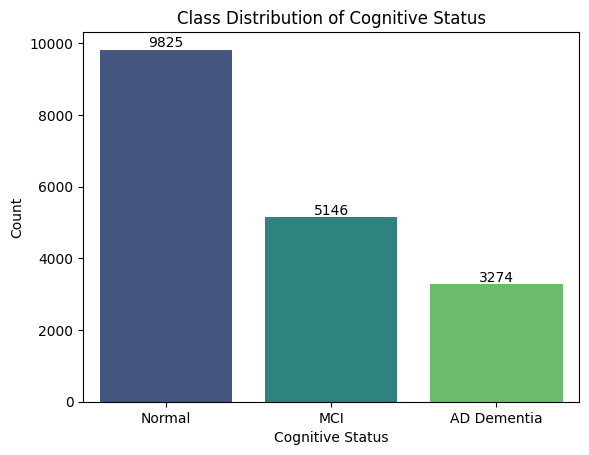

In [21]:
#Target Class Distribution
targetnames = ['Normal', 'MCI', 'AD Dementia']
codes = [0,1,2]
barchart = sns.countplot(x='Target', data=nacc_ml, order=codes, palette='viridis')
#replace x axis number to names
plt.xticks(ticks=[0, 1, 2], labels=targetnames)

#add data label and make sure data label match the bar height
for p in barchart.patches:
    barchart.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'bottom')

plt.title('Class Distribution of Cognitive Status')
plt.xlabel('Cognitive Status')
plt.ylabel('Count')
plt.show()

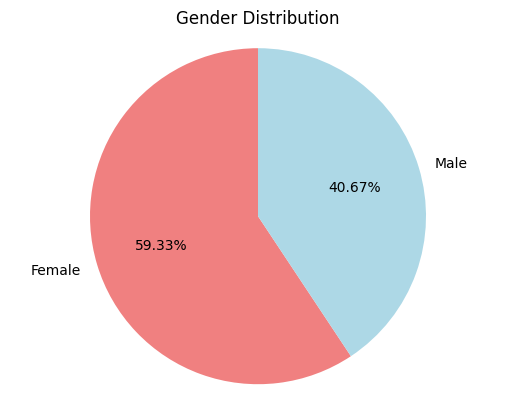

In [22]:
#Sex distribution in Pie chart
sexcount = nacc_ml['SEX_2'].value_counts()
labels = ['Female', 'Male'] 
sizes = [sexcount[1], sexcount[0]]

color = ['lightcoral', 'lightblue']

plt.pie(sizes, labels=labels, colors=color, autopct='%1.2f%%', startangle=90)
plt.axis('equal')
plt.title('Gender Distribution')
plt.show()

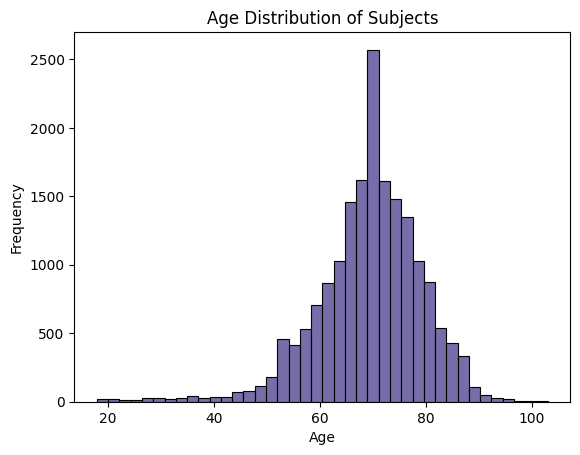

In [23]:
#Age Histogram
sns.histplot(nacc_ml['NACCAGE'], bins=40, color='darkslateblue', edgecolor='black')
plt.title('Age Distribution of Subjects')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

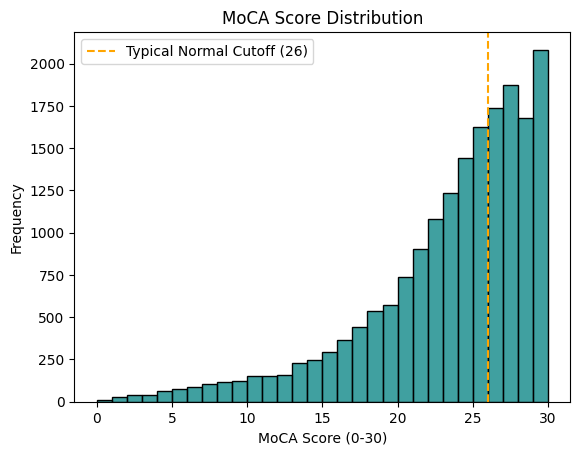

In [24]:
#MoCA score distribution
sns.histplot(nacc_ml['NACCMOCA'], bins=30, color='teal', edgecolor='black')
plt.title('MoCA Score Distribution')
plt.xlabel('MoCA Score (0-30)')
plt.ylabel('Frequency')
#add a vertical line for the "Normal" score (usually 26)
plt.axvline(26, color='orange', linestyle='--', label='Typical Normal Cutoff (26)')
plt.legend()
plt.show()

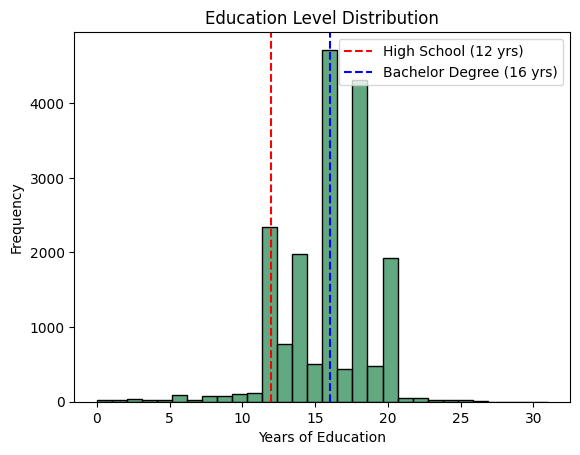

In [25]:
#education histogram
sns.histplot(nacc_ml['EDUC'], bins=30, color='seagreen', edgecolor='black')
plt.title('Education Level Distribution')
plt.xlabel('Years of Education')
plt.ylabel('Frequency')
#put line show high school graduated or university graduated
plt.axvline(12, color='red', linestyle='--', label='High School (12 yrs)')
plt.axvline(16, color='blue', linestyle='--', label='Bachelor Degree (16 yrs)')
plt.legend()

plt.show()

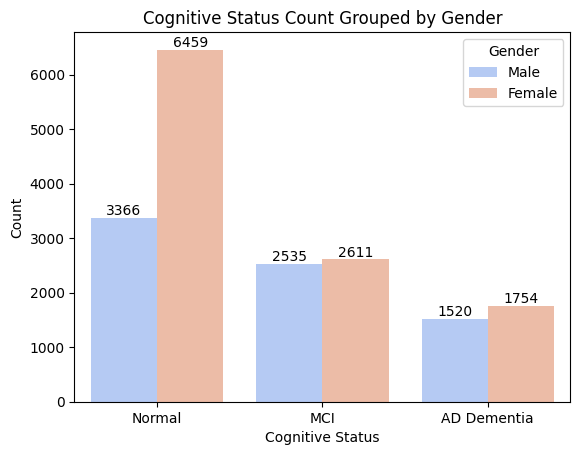

In [26]:
#sex vs diagnosis
sexbar = sns.countplot(x='Target', hue='SEX_2', data=nacc_ml, palette='coolwarm')

#add data label
for p in sexbar.patches:
  if p.get_height() > 0:
    sexbar.annotate(format(p.get_height(), '.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha = 'center', va = 'bottom')

plt.title('Cognitive Status Count Grouped by Gender')
plt.xlabel('Cognitive Status')
plt.ylabel('Count')
plt.xticks(ticks=[0, 1, 2], labels=['Normal', 'MCI', 'AD Dementia'])
plt.legend(title='Gender', labels=['Male', 'Female'])
plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_26952\758363570.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Target', y='NACCMOCA', data=nacc_ml, palette='tab10')


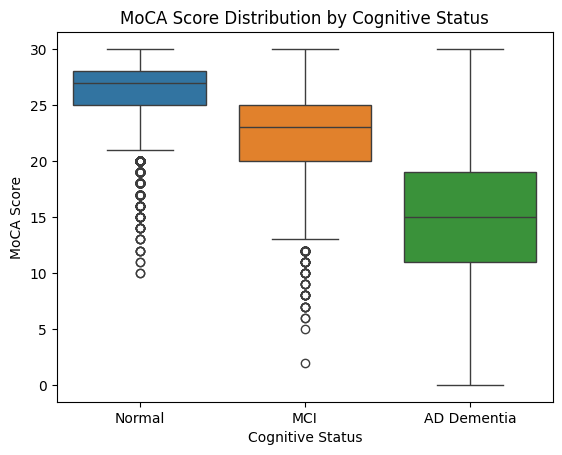

In [27]:
sns.boxplot(x='Target', y='NACCMOCA', data=nacc_ml, palette='tab10')
plt.xticks(ticks=[0, 1, 2], labels=['Normal', 'MCI', 'AD Dementia'])
plt.title('MoCA Score Distribution by Cognitive Status')
plt.xlabel('Cognitive Status')
plt.ylabel('MoCA Score')
plt.show()

# 3. Feature Engineering

## a. Feature Selection

### Step 1: Data Splitting (80:20)

In [28]:
#split first so the Test Set remains a "Real World" benchmark
X = nacc_ml.drop(columns=['Target'])
y = nacc_ml['Target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, 
                                                    random_state=42, stratify=y)

X_train.shape, X_test.shape

((14596, 211), (3649, 211))

### Step 2: Drop Low-Variance Features

In [29]:
#remove features that have 99% same values 
p = 0.99
selector = VarianceThreshold(threshold=(p* (1 - p)))
X_train_reduced = selector.fit_transform(X_train)
X_test_reduced = selector.transform(X_test)

#get the names of the remaining features
selected_cols = X_train.columns[selector.get_support()]

print(f"Features remaining after Variance Threshold: {len(selected_cols)}")

Features remaining after Variance Threshold: 125


### Step 3: Correlation

In [30]:
#Calculate the correlation matrix
#abs() used to catch both strong +ve and strong -ve correlation
X_before_corr = pd.DataFrame(X_train_reduced, columns=selected_cols)
corr_matrix = X_before_corr.corr().abs()

#select upper triangl (triu()) of correlation matrix (to avoid checking pairs twice e.g. AvsB & BvsA)
upper = corr_matrix.where(np.full(corr_matrix.shape, True, dtype=bool) &
                          np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

#get features with correlation more than 0.90 (reduce multicollinearity)
todrop = [column for column in upper.columns if any(upper[column] > 0.90)]

X_train_final = X_before_corr.drop(columns=todrop)
X_test_final = pd.DataFrame(X_test_reduced, columns=selected_cols).drop(columns=todrop)

print(f"Features dropped due to redundancy (>0.90): {len(todrop)}")
print(f"Features remaining after Correlation: {X_train_final.shape[1]}")
print(X_train_final.shape, X_test_final.shape)

Features dropped due to redundancy (>0.90): 4
Features remaining after Correlation: 121
(14596, 121) (3649, 121)


### Step 4: Random Forest Feature Importance

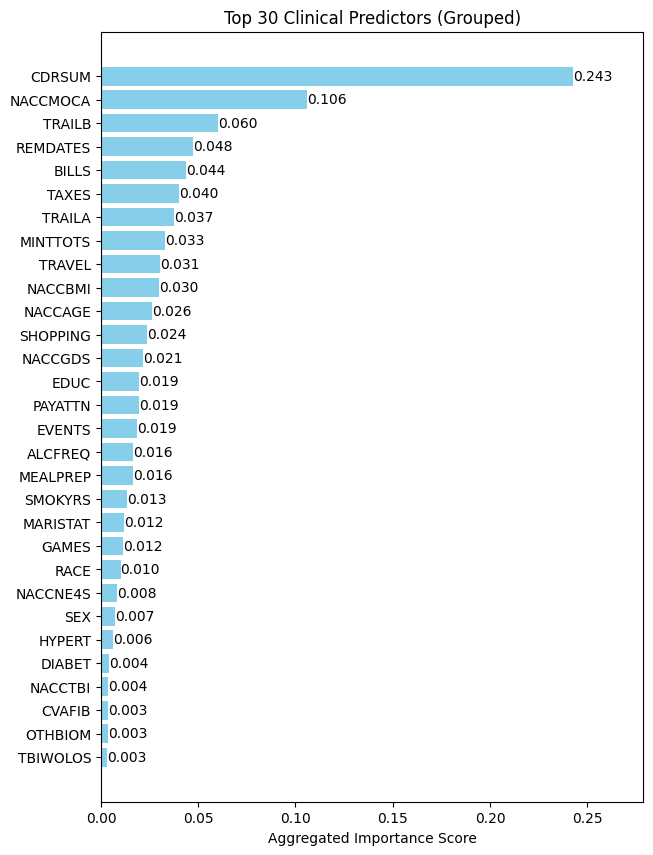

In [31]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_final, y_train)

#take raw importance 
raw_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': rf.feature_importances_
})

#the variable are encoded, so need to group to see the top 30
#Extract the Variable Name (e.g. BILLS_1.0 to BILLS) to see the top 30
raw_importance['Base_var'] = raw_importance['Feature'].apply(lambda x: x.split('_')[0])

#Sum up the importance scores for each base variable
grouped_importance = raw_importance.groupby('Base_var')['Importance'].sum().sort_values(ascending=False).reset_index()

#Visualise Top 30 -_-
top_30 = grouped_importance.head(30)
plt.figure(figsize=(7,10))
plt.barh(top_30['Base_var'][::-1], top_30['Importance'][::-1], color='skyblue')
# Add labels
bars = plt.barh(top_30['Base_var'][::-1], top_30['Importance'][::-1],color='skyblue')
plt.bar_label(bars, fmt='%.3f') #3decimal place
plt.xlim(right=top_30['Importance'].max() * 1.15) #make width wider to prevent the label cross border
plt.xlabel('Aggregated Importance Score')
plt.title('Top 30 Clinical Predictors (Grouped)')
plt.show()

In [32]:
#after checking all 30 variables,  26 features are taken (above 0.005 importance and one more for diabetes)
final_26 = ['CDRSUM', 'NACCMOCA', 'TRAILB', 'REMDATES', 'TRAILA', 'TAXES', 'TRAVEL', 
            'NACCBMI', 'BILLS', 'NACCAGE', 'PAYATTN', 'SHOPPING', 'ALCFREQ',
            'EVENTS', 'NACCGDS', 'EDUC', 'MEALPREP', 'SMOKYRS', 'MARISTAT',
            'GAMES', 'RACE', 'NACCNE4S', 'SEX', 'HYPERT', 'DIABET', 'MINTTOTS']

#extract encoded parts from each variable
final_feature = [col for col in X_train_final.columns 
                 if any(col == feature or col.startswith(feature + '_') 
                        for feature in final_26)]

#create final train and test set
X_train_top = X_train_final[final_feature]
X_test_top = X_test_final[final_feature]

print(f"Total clinical variables: {len(final_26)}")
print(f"Total encoded columns in model: {len(final_feature)}")

Total clinical variables: 26
Total encoded columns in model: 55


## b. Min-Max Scaling

In [33]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_top)
X_test_scaled = scaler.transform(X_test_top)

In [34]:
X_train_s_df = pd.DataFrame(X_train_scaled, columns=X_train_top.columns)

#see how it look like
print("First 5 Rows of Scaled Data")
X_train_s_df.head()

First 5 Rows of Scaled Data


,NACCAGE,EDUC,NACCBMI,NACCMOCA,CDRSUM,NACCGDS,MINTTOTS,TRAILA,TRAILB,SMOKYRS,...,REMDATES_1.0,REMDATES_2.0,REMDATES_3.0,TRAVEL_1.0,TRAVEL_2.0,TRAVEL_3.0,DIABET_2.0,HYPERT_1.0,NACCNE4S_1.0,NACCNE4S_2.0
0,0.682353,0.580645,0.314672,0.833333,0.000000,0.133333,0.96875,0.204225,0.304795,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,0.623529,0.645161,0.279923,0.800000,0.111111,0.066667,1.00000,0.330986,0.143836,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.541176,0.580645,0.303089,0.800000,0.111111,1.000000,1.00000,0.295775,0.284247,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.635294,0.645161,0.353282,0.966667,0.000000,0.533333,0.96875,0.077465,0.195205,0.2,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
4,0.211765,0.516129,0.299228,0.933333,0.000000,0.066667,1.00000,0.063380,0.102740,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


# 4. SMOTETomek for train set

In [35]:
smt = SMOTETomek(random_state=42)
X_train_res, y_train_res = smt.fit_resample(X_train_scaled, y_train)

print(f"Final training set size after SMOTETomek: {X_train_res.shape}")
print(f"Final test set size : {X_test_scaled.shape}")

print("~ Train set Distribution~")
y_train_res.value_counts().sort_index()

Final training set size after SMOTETomek: (22996, 55)
Final test set size : (3649, 55)
~ Train set Distribution~


Target
0    7574
1    7570
2    7852
Name: count, dtype: int64

# 5a. Model 1: Random Forest (RF)

## a. Train Model

In [36]:
#rf model
#import needed library
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_auc_score, ConfusionMatrixDisplay, classification_report

#create rf model and fit train data in rf model
rf = RandomForestClassifier(random_state=42) #use default parameter
rf.fit(X_train_res, y_train_res)

#Get predictions
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)

rfacc = accuracy_score(y_test, y_pred_rf)
rf_report = classification_report(y_test, y_pred_rf, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)
rf_auc = roc_auc_score(y_test, y_proba_rf, multi_class='ovr') #One-vs-Rest for 3 class
#function to calculate specificity
def calculate_specificity(conf_matrix):
    specificity = [] #tn / (tn + fp) formula ...
    for i in range(len(conf_matrix)):
        tn = np.sum(conf_matrix) - (np.sum(conf_matrix[:, i]) + np.sum(conf_matrix[i, :]) - conf_matrix[i, i])
        fp = np.sum(conf_matrix[:, i]) - conf_matrix[i, i]
        specificity.append(tn / (tn + fp))
    return np.mean(specificity)

rf_cm = confusion_matrix(y_test, y_pred_rf)
rf_spec = calculate_specificity(rf_cm)

print("Random Forest Model performance Before Tunning:")
print(f"Accuracy:    {rfacc:.4f}")
print(f"Specificity: {rf_spec:.4f}")
print(f"AUC-ROC:     {rf_auc:.4f}")

print("\nClassification Report:\n", rf_report)

Random Forest Model performance Before Tunning:
Accuracy:    0.8589
Specificity: 0.9276
AUC-ROC:     0.9517

Classification Report:
               precision    recall  f1-score   support

      Normal     0.9356    0.9013    0.9181      1965
         MCI     0.7392    0.7823    0.7602      1029
 AD Dementia     0.8366    0.8519    0.8442       655

    accuracy                         0.8589      3649
   macro avg     0.8371    0.8452    0.8408      3649
weighted avg     0.8624    0.8589    0.8603      3649



## b. Visualise the Confusion Matrix & ROC Curve

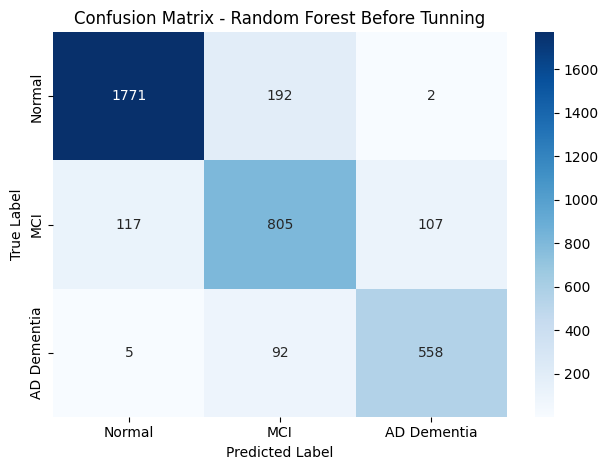

In [37]:
#heatmap confusion metrix before prun
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - Random Forest Before Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

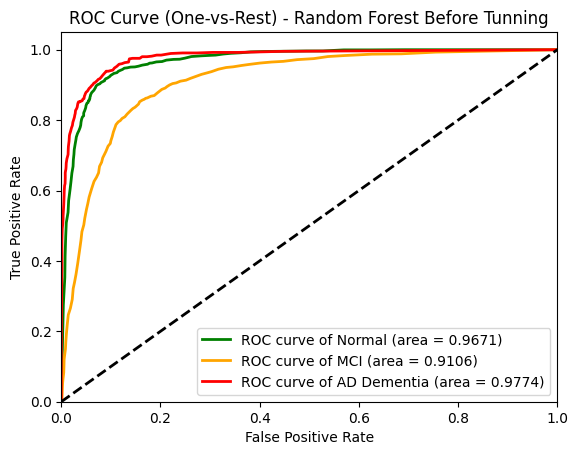

In [38]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

#make the output become binary for multiclass plotting
y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_num = y_test_bin.shape[1]

colors = ['green', 'orange', 'red']
targetnames = ['Normal', 'MCI', 'AD Dementia']

for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Random Forest Before Tunning')
plt.legend(loc="lower right")
plt.show()

## c. Hyperparameter Tuning

In [39]:
import optuna
from sklearn.model_selection import StratifiedKFold, cross_val_score

def rfmodel(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 500),
        'max_depth': trial.suggest_int('max_depth', 5, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 5),
        'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2'])
    }
    rfmodel = RandomForestClassifier(**params, random_state= 42)
    #use 5 cross-validation on resampled train data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(rfmodel, X_train_res, y_train_res,
                          cv=cv, scoring='roc_auc_ovr', n_jobs=-1).mean()

#study
rfstudy = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42)) #for reprductivity
rfstudy.optimize(rfmodel, n_trials=50)

#get best parameter
print(f"Best Trial Score (AUC): {rfstudy.best_value:.4f}")
print("Best Params:", rfstudy.best_params)

c:\Users\User\Documents\FYP\Predictive Model\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-04-20 16:39:45,511] A new study created in memory with name: no-name-562015a2-c17a-4e25-88a1-7eb946df0a5a
[I 2026-04-20 16:39:54,469] Trial 0 finished with value: 0.9741292883863585 and parameters: {'n_estimators': 250, 'max_depth': 48, 'min_samples_split': 15, 'min_samples_leaf': 3, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.9741292883863585.
[I 2026-04-20 16:39:58,768] Trial 1 finished with value: 0.9726430312745153 and parameters: {'n_estimators': 123, 'max_depth': 44, 'min_samples_split': 13, 'min_samples_leaf': 4, 'max_features': 'log2'}. Best is trial 0 with value: 0.9741292883863585.
[I 2026-04-20 16:40:09,147] Trial 2 finished with value: 0.9720056189759718 and parameters: {'n_estimators': 

Best Trial Score (AUC): 0.9808
Best Params: {'n_estimators': 451, 'max_depth': 49, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2'}


In [40]:
#fit
best_rf = RandomForestClassifier(**rfstudy.best_params,
                                 random_state=42)
best_rf.fit(X_train_res, y_train_res)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",451
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",49
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

## d. Evaluate Model with Test Set

In [41]:
#use best model to predict
y_pred_best_rf = best_rf.predict(X_test_scaled)
y_proba_best_rf = best_rf.predict_proba(X_test_scaled)

final_rfacc = accuracy_score(y_test, y_pred_best_rf)
final_rfauc = roc_auc_score(y_test, y_proba_best_rf, multi_class='ovr')
final_rfcm = confusion_matrix(y_test, y_pred_best_rf)
final_rfspec = calculate_specificity(final_rfcm)
final_rfreport = classification_report(y_test, y_pred_best_rf, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)

print("Random Forest Model Performance After Tunning:")
print(f"Final Accuracy: {final_rfacc:.4f}")
print(f"Specificity: {final_rfspec:.4f}")
print(f"Final AUC-ROC:  {final_rfauc:.4f}")
print("\nClassification Report:\n", final_rfreport)

Random Forest Model Performance After Tunning:
Final Accuracy: 0.8605
Specificity: 0.9286
Final AUC-ROC:  0.9534

Classification Report:
               precision    recall  f1-score   support

      Normal     0.9372    0.9038    0.9202      1965
         MCI     0.7431    0.7813    0.7617      1029
 AD Dementia     0.8333    0.8550    0.8440       655

    accuracy                         0.8605      3649
   macro avg     0.8379    0.8467    0.8420      3649
weighted avg     0.8638    0.8605    0.8618      3649



## e. Visualise the Confusion Matrix & ROC Curve After Tuning

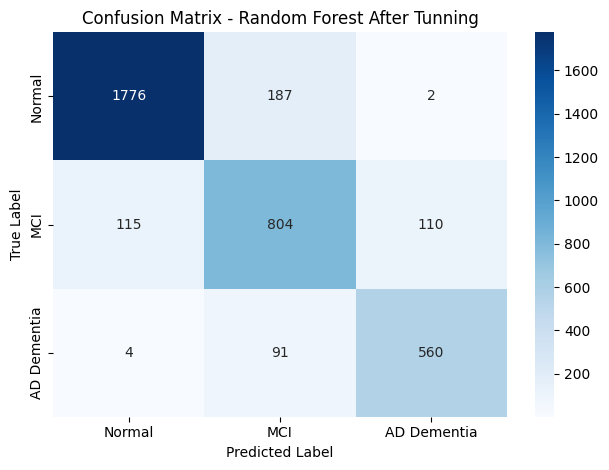

In [42]:
#heatmap confusion metrix after prun
sns.heatmap(final_rfcm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - Random Forest After Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

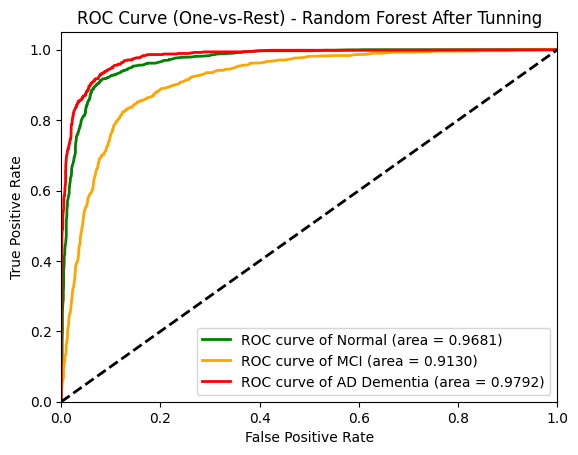

In [43]:
#roc curve
for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best_rf[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - Random Forest After Tunning')
plt.legend(loc="lower right")
plt.show()

# 5b. Model 2: Extreme Gradient Boosting (XGBoost)

## a. Train Model

In [44]:
#xgb model
#import needed library
import xgboost as xg

#create xgb model and fit train data in xgb model
xgb = xg.XGBClassifier(objective='multi:softprob', #multiclass
                       num_class=3,
                       eval_metric='mlogloss',
                       n_estimators=100,
                       learning_rate=0.05,
                       max_depth=6,
                       random_state=42,
                       n_jobs=-1)

xgb.fit(X_train_res, y_train_res)

#Get predictions
y_pred_xgb = xgb.predict(X_test_scaled)
y_proba_xgb = xgb.predict_proba(X_test_scaled)

xgbacc = accuracy_score(y_test, y_pred_xgb)
xgb_report = classification_report(y_test, y_pred_xgb, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)
xgb_auc = roc_auc_score(y_test, y_proba_xgb, multi_class='ovr') #One-vs-Rest for 3 class

xgb_cm = confusion_matrix(y_test, y_pred_xgb)
xgb_spec = calculate_specificity(xgb_cm)

print("XGBoost Model performance Before Tunning:")
print(f"Accuracy:    {xgbacc:.4f}")
print(f"Specificity: {xgb_spec:.4f}")
print(f"AUC-ROC:     {xgb_auc:.4f}")

print("\nClassification Report:\n", xgb_report)

XGBoost Model performance Before Tunning:
Accuracy:    0.8542
Specificity: 0.9248
AUC-ROC:     0.9539

Classification Report:
               precision    recall  f1-score   support

      Normal     0.9314    0.8987    0.9148      1965
         MCI     0.7311    0.7794    0.7545      1029
 AD Dementia     0.8369    0.8382    0.8375       655

    accuracy                         0.8542      3649
   macro avg     0.8331    0.8388    0.8356      3649
weighted avg     0.8580    0.8542    0.8557      3649



## b. Visualise the Confusion Matrix & ROC Curve

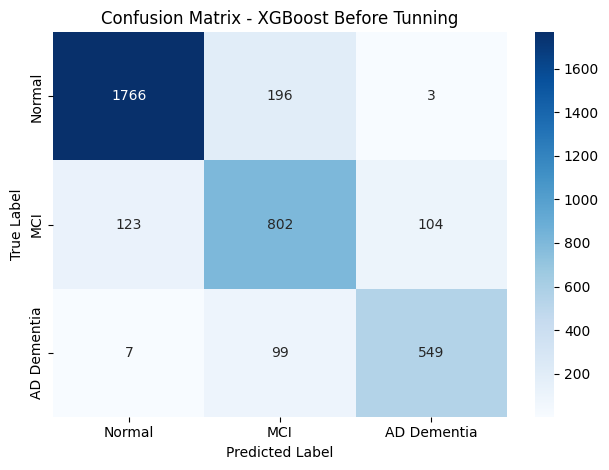

In [45]:
#heatmap confusion metrix before prun
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - XGBoost Before Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

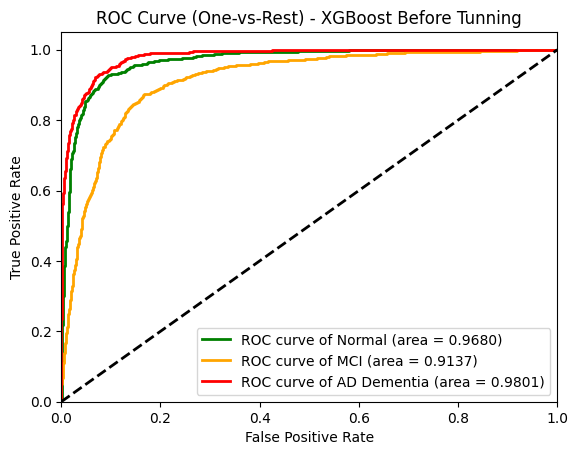

In [46]:
#roc curve
for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - XGBoost Before Tunning')
plt.legend(loc="lower right")
plt.show()

## c. Hyperparameter Tuning

In [47]:
def xgbmodel(trial):
    params = {
        'objective': 'multi:softprob',
        'num_class': len(np.unique(y_train_res)),
        'random_state': 42,
        'eval_metric': 'mlogloss',
        #hyperparameter to tune
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 5)
    }
    xgbmodel = xg.XGBClassifier(**params)
    #use 5 cross-validation on resampled train data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(xgbmodel, X_train_res, y_train_res,
                          cv=cv, scoring='roc_auc_ovr', n_jobs=-1).mean()

#study
xgbstudy = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42)) #for reprductivity
xgbstudy.optimize(xgbmodel, n_trials=50)

#get best parameter
print(f"Best Trial Score (AUC): {xgbstudy.best_value:.4f}")
print("Best Params:", xgbstudy.best_params)

[I 2026-04-20 16:48:03,640] A new study created in memory with name: no-name-cdef344b-56b4-4bab-9778-0e0bee8a89d8
[I 2026-04-20 16:48:26,519] Trial 0 finished with value: 0.9806895201465945 and parameters: {'n_estimators': 437, 'max_depth': 15, 'learning_rate': 0.08960785365368121, 'subsample': 0.8394633936788146, 'min_child_weight': 2, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.2904180608409973}. Best is trial 0 with value: 0.9806895201465945.
[I 2026-04-20 16:48:43,291] Trial 1 finished with value: 0.9783523149128763 and parameters: {'n_estimators': 880, 'max_depth': 10, 'learning_rate': 0.08341106432362087, 'subsample': 0.608233797718321, 'min_child_weight': 10, 'colsample_bytree': 0.9162213204002109, 'gamma': 1.0616955533913808}. Best is trial 0 with value: 0.9806895201465945.
[I 2026-04-20 16:48:50,959] Trial 2 finished with value: 0.9699562001489532 and parameters: {'n_estimators': 263, 'max_depth': 5, 'learning_rate': 0.024878734419814436, 'subsample': 0.8099025726528951

Best Trial Score (AUC): 0.9816
Best Params: {'n_estimators': 841, 'max_depth': 10, 'learning_rate': 0.044746820165869214, 'subsample': 0.828482544111669, 'min_child_weight': 3, 'colsample_bytree': 0.9858603245332513, 'gamma': 0.015972955376689274}


In [48]:
#fit
best_xgb = xg.XGBClassifier(**xgbstudy.best_params, 
                            objective='multi:softprob',
                            num_class=len(np.unique(y_train_res)),
                            random_state=42,           
                            eval_metric= 'mlogloss')
best_xgb.fit(X_train_res, y_train_res)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.9858603245332513
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegress

## d. Evaluate Model with Test Set

In [49]:
#use best model to predict
y_pred_best_xgb = best_xgb.predict(X_test_scaled)
y_proba_best_xgb= best_xgb.predict_proba(X_test_scaled)

final_xgbacc = accuracy_score(y_test, y_pred_best_xgb)
final_xgbauc = roc_auc_score(y_test, y_proba_best_xgb, multi_class='ovr')
final_xgbcm = confusion_matrix(y_test, y_pred_best_xgb)
final_xgbspec = calculate_specificity(final_xgbcm)
final_xgbreport = classification_report(y_test, y_pred_best_xgb, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)

print("XGBoost Model Performance After Tunning:")
print(f"Final Accuracy: {final_xgbacc:.4f}")
print(f"Specificity: {final_xgbspec:.4f}")
print(f"Final AUC-ROC:  {final_xgbauc:.4f}")
print("\nClassification Report:\n", final_xgbreport)

XGBoost Model Performance After Tunning:
Final Accuracy: 0.8545
Specificity: 0.9230
Final AUC-ROC:  0.9510

Classification Report:
               precision    recall  f1-score   support

      Normal     0.9203    0.9115    0.9159      1965
         MCI     0.7364    0.7629    0.7494      1029
 AD Dementia     0.8509    0.8275    0.8390       655

    accuracy                         0.8545      3649
   macro avg     0.8359    0.8339    0.8348      3649
weighted avg     0.8560    0.8545    0.8551      3649



## e. Visualise the Confusion Matrix & ROC Curve After Tuning

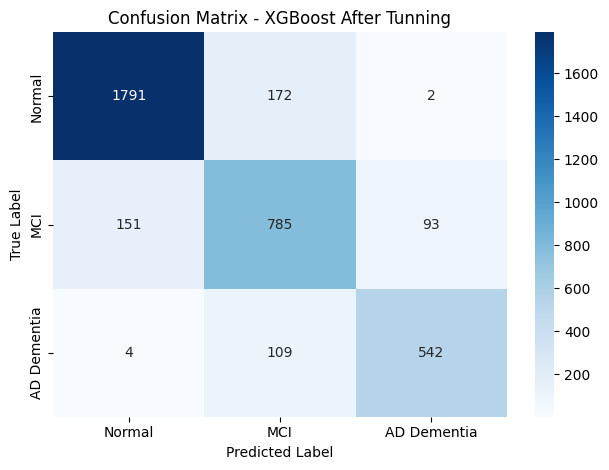

In [50]:
#heatmap confusion metrix after prun
sns.heatmap(final_xgbcm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - XGBoost After Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

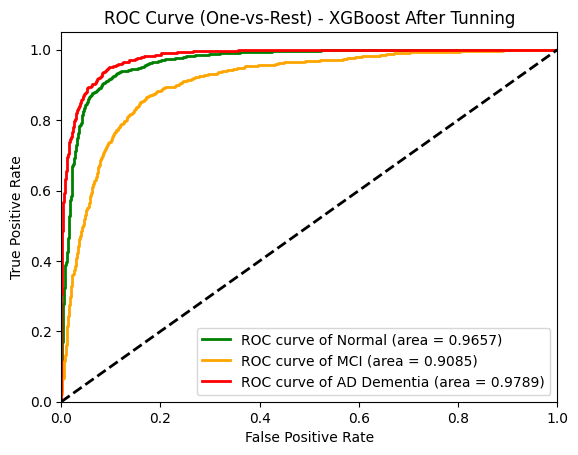

In [51]:
#roc curve
for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best_xgb[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - XGBoost After Tunning')
plt.legend(loc="lower right")
plt.show()

# 5c. Model 3: Light Gradient Boosting Machine (LightGBM)

## a. Train Model

In [52]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(           
    objective='multiclass',#multiclass
    num_class=len(np.unique(y_train_res)),
    metric= "multi_logloss",           
    random_state=42,
    n_estimators=100,
    learning_rate=0.1,
    n_jobs=-1
)

lgbm.fit(X_train_res, y_train_res)

#Get predictions
y_pred_lgbm = lgbm.predict(X_test_scaled)
y_proba_lgbm = lgbm.predict_proba(X_test_scaled)

lgbmacc = accuracy_score(y_test, y_pred_lgbm)
lgbm_report = classification_report(y_test, y_pred_lgbm, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)
lgbm_auc = roc_auc_score(y_test, y_proba_lgbm, multi_class='ovr') #One-vs-Rest for 3 class

lgbm_cm = confusion_matrix(y_test, y_pred_lgbm)
lgbm_spec = calculate_specificity(lgbm_cm)

print("LightGBM Model performance Before Tunning:")
print(f"Accuracy:    {lgbmacc:.4f}")
print(f"Specificity: {lgbm_spec:.4f}")
print(f"AUC-ROC:     {lgbm_auc:.4f}")

print("\nClassification Report:\n", lgbm_report)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003820 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 12396
[LightGBM] [Info] Number of data points in the train set: 22996, number of used features: 55
[LightGBM] [Info] Start training from score -1.110599
[LightGBM] [Info] Start training from score -1.111127
[LightGBM] [Info] Start training from score -1.074552
LightGBM Model performance Before Tunning:
Accuracy:    0.8534
Specificity: 0.9227
AUC-ROC:     0.9530

Classification Report:
               precision    recall  f1-score   support

      Normal     0.9206    0.9150    0.9178      1965
         MCI     0.7409    0.7502    0.7455      1029
 AD Dementia     0.8318    0.8305    0.8312       655

    accuracy                         0.8534      3649
   macro avg     0.8311    0.8319    0.8315      3649
weighted avg     0.8540    0.8

c:\Users\User\Documents\FYP\Predictive Model\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
c:\Users\User\Documents\FYP\Predictive Model\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## b. Visualise the Confusion Matrix & ROC Curve

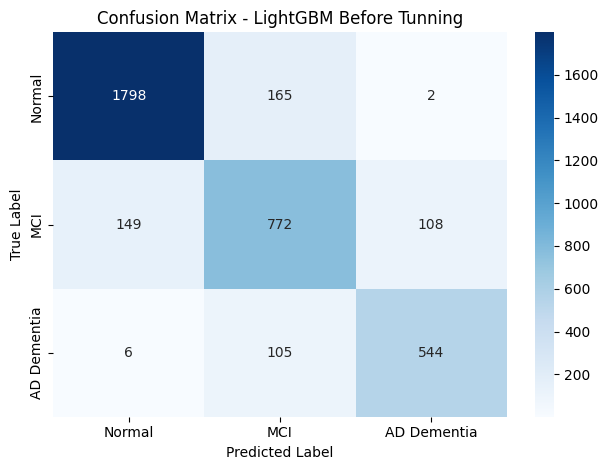

In [53]:
#heatmap confusion metrix before prun
sns.heatmap(lgbm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - LightGBM Before Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

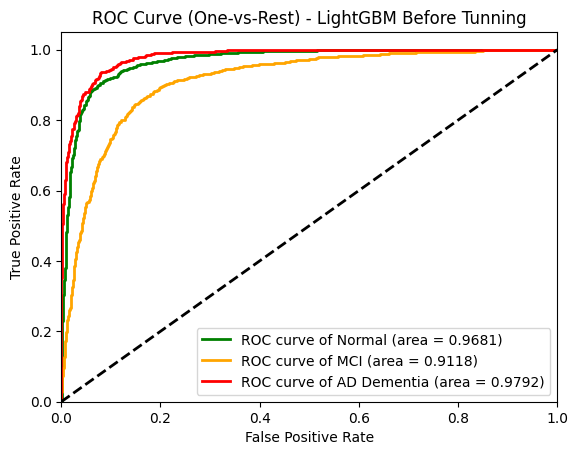

In [54]:
#roc curve
for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_lgbm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - LightGBM Before Tunning')
plt.legend(loc="lower right")
plt.show()

## c. Hyperparameter Tuning

In [55]:
def lgbmmodel(trial):
    params = {
        'objective': 'multiclass',
        'num_class':len(np.unique(y_train_res)),
        'random_state': 42,
        "metric": "multi_logloss",
        "n_jobs": -1,
        #hyperparameter to tune
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 15),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.4, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.4, 1.0),
        'bagging_freq': trial.suggest_int('bagging_freq', 1, 7),
        'min_child_samples': trial.suggest_int('min_child_samples', 5, 50)
    }
    lgbmmodel = LGBMClassifier(**params)
    #use 5 cross-validation on resampled train data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(lgbmmodel, X_train_res, y_train_res,
                          cv=cv, scoring='roc_auc_ovr', n_jobs=-1).mean()

#study
lgbmstudy = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42)) #for reprductivity
lgbmstudy.optimize(lgbmmodel, n_trials=50)

#get best parameter
print(f"Best Trial Score (AUC): {lgbmstudy.best_value:.4f}")
print("Best Params:", lgbmstudy.best_params)

[I 2026-04-20 17:07:41,189] A new study created in memory with name: no-name-3233bff2-7fb0-4003-9f1f-9f34263cc1ed
[I 2026-04-20 17:08:10,775] Trial 0 finished with value: 0.9802653258567362 and parameters: {'n_estimators': 437, 'learning_rate': 0.2536999076681772, 'max_depth': 12, 'num_leaves': 98, 'feature_fraction': 0.4936111842654619, 'bagging_fraction': 0.49359671220172163, 'bagging_freq': 1, 'min_child_samples': 44}. Best is trial 0 with value: 0.9802653258567362.
[I 2026-04-20 17:08:17,376] Trial 1 finished with value: 0.9760585332471706 and parameters: {'n_estimators': 641, 'learning_rate': 0.11114989443094977, 'max_depth': 3, 'num_leaves': 147, 'feature_fraction': 0.899465584480253, 'bagging_fraction': 0.5274034664069657, 'bagging_freq': 2, 'min_child_samples': 13}. Best is trial 0 with value: 0.9802653258567362.
[I 2026-04-20 17:08:33,763] Trial 2 finished with value: 0.980033987145909 and parameters: {'n_estimators': 374, 'learning_rate': 0.05958389350068958, 'max_depth': 8, 

Best Trial Score (AUC): 0.9832
Best Params: {'n_estimators': 900, 'learning_rate': 0.04291949299547324, 'max_depth': 13, 'num_leaves': 109, 'feature_fraction': 0.9181575846896559, 'bagging_fraction': 0.7267688034077343, 'bagging_freq': 4, 'min_child_samples': 5}


In [56]:
#fit
best_lgbm = LGBMClassifier(**lgbmstudy.best_params, 
                            objective='multiclass',
                            num_class=len(np.unique(y_train_res)),
                            random_state=42,           
                            metric= "multi_logloss")
best_lgbm.fit(X_train_res, y_train_res)

[LightGBM] [Warning] feature_fraction is set=0.9181575846896559, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9181575846896559
[LightGBM] [Warning] bagging_fraction is set=0.7267688034077343, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7267688034077343
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Warning] feature_fraction is set=0.9181575846896559, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9181575846896559
[LightGBM] [Warning] bagging_fraction is set=0.7267688034077343, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7267688034077343
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003828 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not

,boosting_type,'gbdt'
,num_leaves,109
,max_depth,13
,learning_rate,0.04291949299547324
,n_estimators,900
,subsample_for_bin,200000
,objective,'multiclass'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,5


## d. Evaluate Model with Test Set

In [57]:
#use best model to predict
y_pred_best_lgbm = best_lgbm.predict(X_test_scaled)
y_proba_best_lgbm= best_lgbm.predict_proba(X_test_scaled)

final_lgbmacc = accuracy_score(y_test, y_pred_best_lgbm)
final_lgbmauc = roc_auc_score(y_test, y_proba_best_lgbm, multi_class='ovr')
final_lgbmcm = confusion_matrix(y_test, y_pred_best_lgbm)
final_lgbmspec = calculate_specificity(final_lgbmcm)
final_lgbmreport = classification_report(y_test, y_pred_best_lgbm, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)

print("LightGBM Model Performance After Tunning:")
print(f"Final Accuracy: {final_lgbmacc:.4f}")
print(f"Specificity: {final_lgbmspec:.4f}")
print(f"Final AUC-ROC:  {final_lgbmauc:.4f}")
print("\nClassification Report:\n", final_lgbmreport)

c:\Users\User\Documents\FYP\Predictive Model\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.9181575846896559, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9181575846896559
[LightGBM] [Warning] bagging_fraction is set=0.7267688034077343, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7267688034077343
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4


c:\Users\User\Documents\FYP\Predictive Model\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] feature_fraction is set=0.9181575846896559, colsample_bytree=1.0 will be ignored. Current value: feature_fraction=0.9181575846896559
[LightGBM] [Warning] bagging_fraction is set=0.7267688034077343, subsample=1.0 will be ignored. Current value: bagging_fraction=0.7267688034077343
[LightGBM] [Warning] bagging_freq is set=4, subsample_freq=0 will be ignored. Current value: bagging_freq=4
LightGBM Model Performance After Tunning:
Final Accuracy: 0.8583
Specificity: 0.9246
Final AUC-ROC:  0.9519

Classification Report:
               precision    recall  f1-score   support

      Normal     0.9201    0.9196    0.9198      1965
         MCI     0.7450    0.7638    0.7543      1029
 AD Dementia     0.8556    0.8229    0.8389       655

    accuracy                         0.8583      3649
   macro avg     0.8402    0.8354    0.8377      3649
weighted avg     0.8591    0.8583    0.8586      3649



## e. Visualise the Confusion Matrix & ROC Curve After Tuning

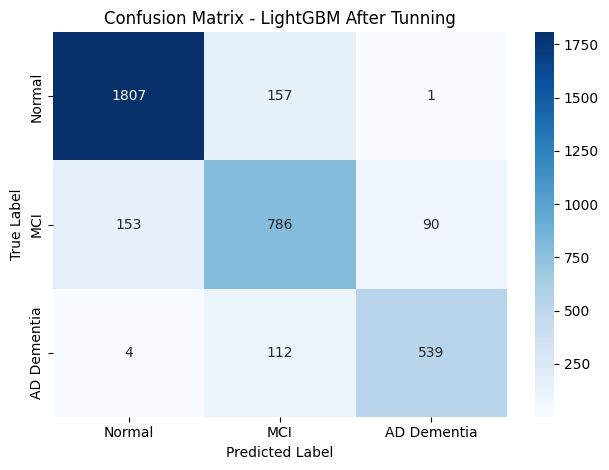

In [58]:
#heatmap confusion metrix before prun
sns.heatmap(final_lgbmcm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - LightGBM After Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

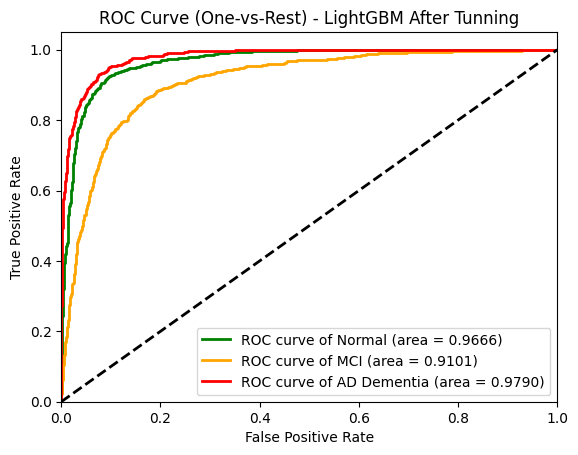

In [59]:
#roc curve
for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best_lgbm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - LightGBM After Tunning')
plt.legend(loc="lower right")
plt.show()

# 5d. Model 4: Support Vector Machine (SVM)

## a. Train Model

In [60]:
from sklearn.svm import SVC

svm = SVC(
    kernel='rbf',   
    C=1.0, # regularissation, default          
    gamma='scale',     #kernel coefficient
    probability=True,  #need for SHAP and AUC
    random_state=42
)

svm.fit(X_train_res, y_train_res)

#Get predictions
y_pred_svm = svm.predict(X_test_scaled)
y_proba_svm = svm.predict_proba(X_test_scaled)

svmacc = accuracy_score(y_test, y_pred_svm)
svm_report = classification_report(y_test, y_pred_svm, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)
svm_auc = roc_auc_score(y_test, y_proba_svm, multi_class='ovr') #One-vs-Rest for 3 class

svm_cm = confusion_matrix(y_test, y_pred_svm)
svm_spec = calculate_specificity(svm_cm)

print("SVM Model performance Before Tunning:")
print(f"Accuracy:    {svmacc:.4f}")
print(f"Specificity: {svm_spec:.4f}")
print(f"AUC-ROC:     {svm_auc:.4f}")

print("\nClassification Report:\n", svm_report)

SVM Model performance Before Tunning:
Accuracy:    0.8139
Specificity: 0.9016
AUC-ROC:     0.9308

Classification Report:
               precision    recall  f1-score   support

      Normal     0.8967    0.8743    0.8853      1965
         MCI     0.6673    0.6900    0.6785      1029
 AD Dementia     0.8102    0.8275    0.8187       655

    accuracy                         0.8139      3649
   macro avg     0.7914    0.7973    0.7942      3649
weighted avg     0.8165    0.8139    0.8150      3649



## b. Visualise the Confusion Matrix & ROC Curve

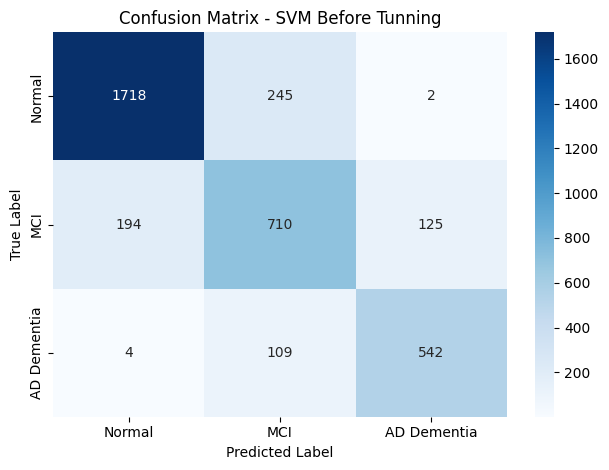

In [61]:
#heatmap confusion metrix before prun
sns.heatmap(svm_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - SVM Before Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

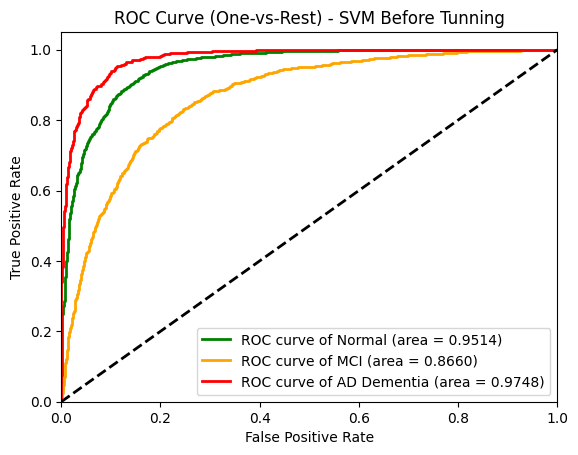

In [62]:
#roc curve
for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - SVM Before Tunning')
plt.legend(loc="lower right")
plt.show()

## c. Hyperparameter Tuning

In [63]:
def svmmodel(trial):
    params = {
        'C': trial.suggest_float('C', 0.1, 100, log=True),
        'gamma': trial.suggest_float('gamma', 1e-4, 1, log=True),
        'kernel': trial.suggest_categorical('kernel', ['rbf', 'sigmoid']),
        'probability': True,
        'random_state': 42
    }
    svmmodel = SVC(**params)
    #use 5 cross-validation on resampled train data
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    return cross_val_score(svmmodel, X_train_res, y_train_res,
                          cv=cv, scoring='roc_auc_ovr', n_jobs=-1).mean()

#study
svmstudy = optuna.create_study(direction='maximize',
                            sampler=optuna.samplers.TPESampler(seed=42)) #for reprductivity
svmstudy.optimize(svmmodel, n_trials=50)

#get best parameter
print(f"Best Trial Score (AUC): {svmstudy.best_value:.4f}")
print("Best Params:", svmstudy.best_params)

[I 2026-04-20 17:47:45,648] A new study created in memory with name: no-name-b4008274-8b29-40e7-aa72-dc4bb8d1c35a
[I 2026-04-20 17:52:02,689] Trial 0 finished with value: 0.9702071790183291 and parameters: {'C': 1.3292918943162166, 'gamma': 0.6351221010640696, 'kernel': 'rbf'}. Best is trial 0 with value: 0.9702071790183291.
[I 2026-04-20 18:00:49,538] Trial 1 finished with value: 0.8684681319364385 and parameters: {'C': 0.2938027938703535, 'gamma': 0.0004207053950287938, 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.9702071790183291.
[I 2026-04-20 18:03:04,856] Trial 2 finished with value: 0.8754148886578363 and parameters: {'C': 6.358358856676251, 'gamma': 0.06796578090758151, 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.9702071790183291.
[I 2026-04-20 18:06:06,102] Trial 3 finished with value: 0.9294618624491194 and parameters: {'C': 31.428808908401084, 'gamma': 0.0007068974950624604, 'kernel': 'sigmoid'}. Best is trial 0 with value: 0.9702071790183291.
[I 2026-04-20 18

Best Trial Score (AUC): 0.9793
Best Params: {'C': 20.306904496200293, 'gamma': 0.5382050201479855, 'kernel': 'rbf'}


In [64]:
#fit
best_svm = SVC(**svmstudy.best_params, 
                probability=True,       
                random_state=42)
best_svm.fit(X_train_res, y_train_res)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",20.306904496200293
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.5382050201479855
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


## d. Evaluate Model with Test Set

In [65]:
#use best model to predict
y_pred_best_svm = best_svm.predict(X_test_scaled)
y_proba_best_svm= best_svm.predict_proba(X_test_scaled)

final_svmacc = accuracy_score(y_test, y_pred_best_svm)
final_svmauc = roc_auc_score(y_test, y_proba_best_svm, multi_class='ovr')
final_svmcm = confusion_matrix(y_test, y_pred_best_svm)
final_svmspec = calculate_specificity(final_svmcm)
final_svmreport = classification_report(y_test, y_pred_best_svm, target_names=['Normal', 'MCI', 'AD Dementia'], digits=4)

print("SVM Model Performance After Tunning:")
print(f"Final Accuracy: {final_svmacc:.4f}")
print(f"Specificity: {final_svmspec:.4f}")
print(f"Final AUC-ROC:  {final_svmauc:.4f}")
print("\nClassification Report:\n", final_svmreport)

SVM Model Performance After Tunning:
Final Accuracy: 0.7967
Specificity: 0.8910
Final AUC-ROC:  0.9179

Classification Report:
               precision    recall  f1-score   support

      Normal     0.8774    0.8885    0.8829      1965
         MCI     0.6552    0.6093    0.6314      1029
 AD Dementia     0.7607    0.8153    0.7870       655

    accuracy                         0.7967      3649
   macro avg     0.7644    0.7710    0.7671      3649
weighted avg     0.7938    0.7967    0.7948      3649



## e. Visualise the Confusion Matrix & ROC Curve After Tuning

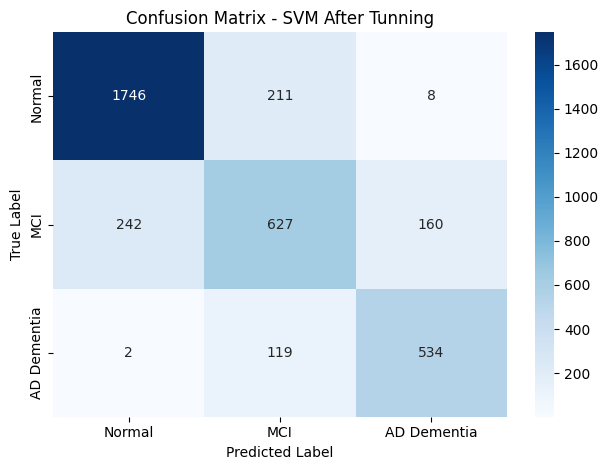

In [66]:
#heatmap confusion metrix after prun
sns.heatmap(final_svmcm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'MCI', 'AD Dementia'],
            yticklabels=['Normal', 'MCI', 'AD Dementia'])

plt.title('Confusion Matrix - SVM After Tunning')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')

plt.tight_layout()
plt.show()

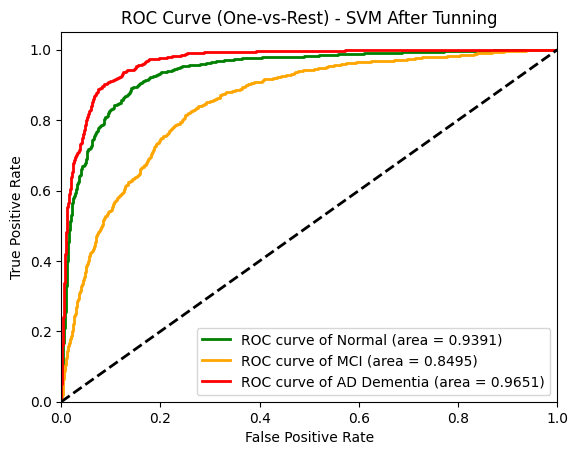

In [67]:
#roc curve
for i in range(class_num):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_best_svm[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=colors[i], lw=2,
             label=f'ROC curve of {targetnames[i]} (area = {roc_auc:0.4f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2) #diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve (One-vs-Rest) - SVM After Tunning')
plt.legend(loc="lower right")
plt.show()

# 6. SHAP analysis for Random Forest

In [68]:
#convert to dataframe so shap can show feature name
X_test_scaled_df = pd.DataFrame(
    X_test_scaled,
    columns=final_feature, 
    index=X_test_top.index
)

In [69]:
import shap

#rf is the most best performing model
rf_explainer = shap.TreeExplainer(best_rf)

# Calculate SHAP values 
shap_values = rf_explainer.shap_values(X_test_scaled_df)
shap_values_MCI = shap_values[:, :, 1] #for mci case
shap_values_AD  = shap_values[:, :, 2] #for ad dementia case


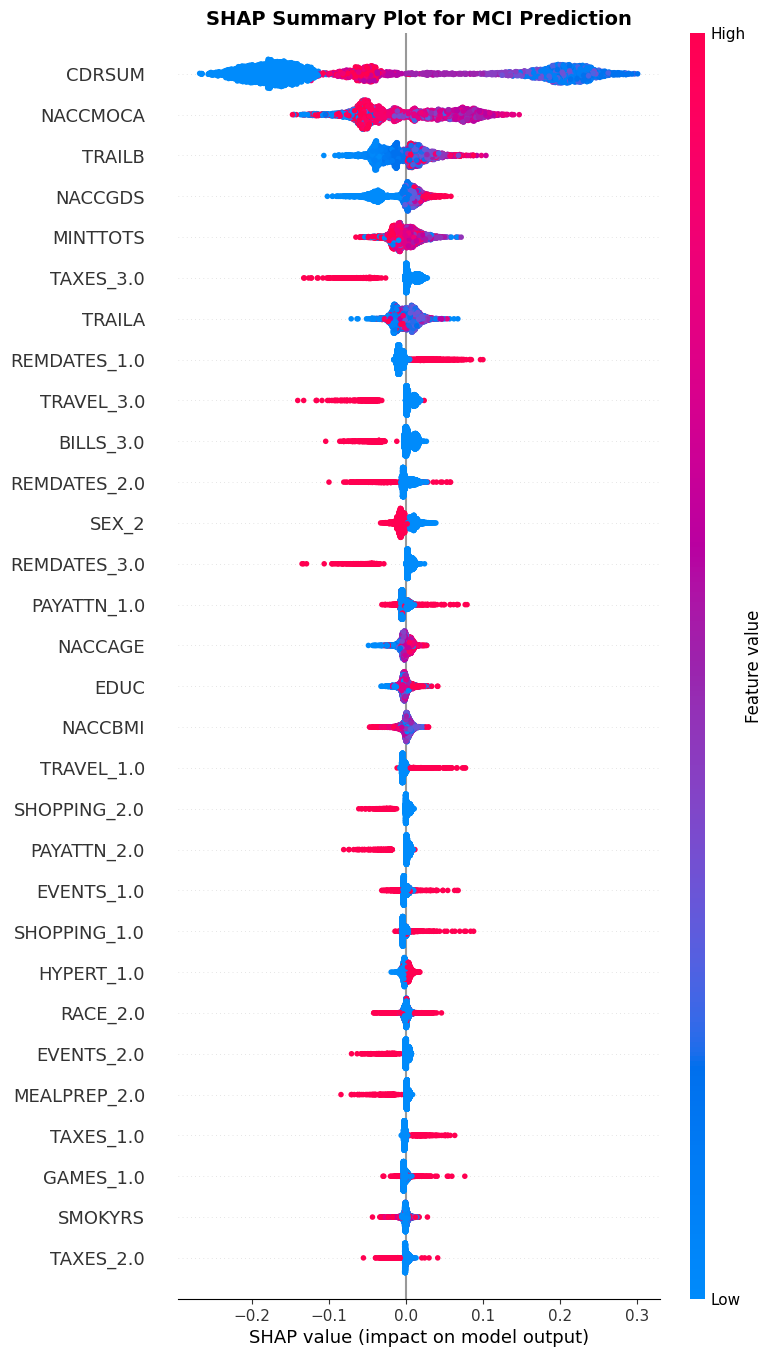

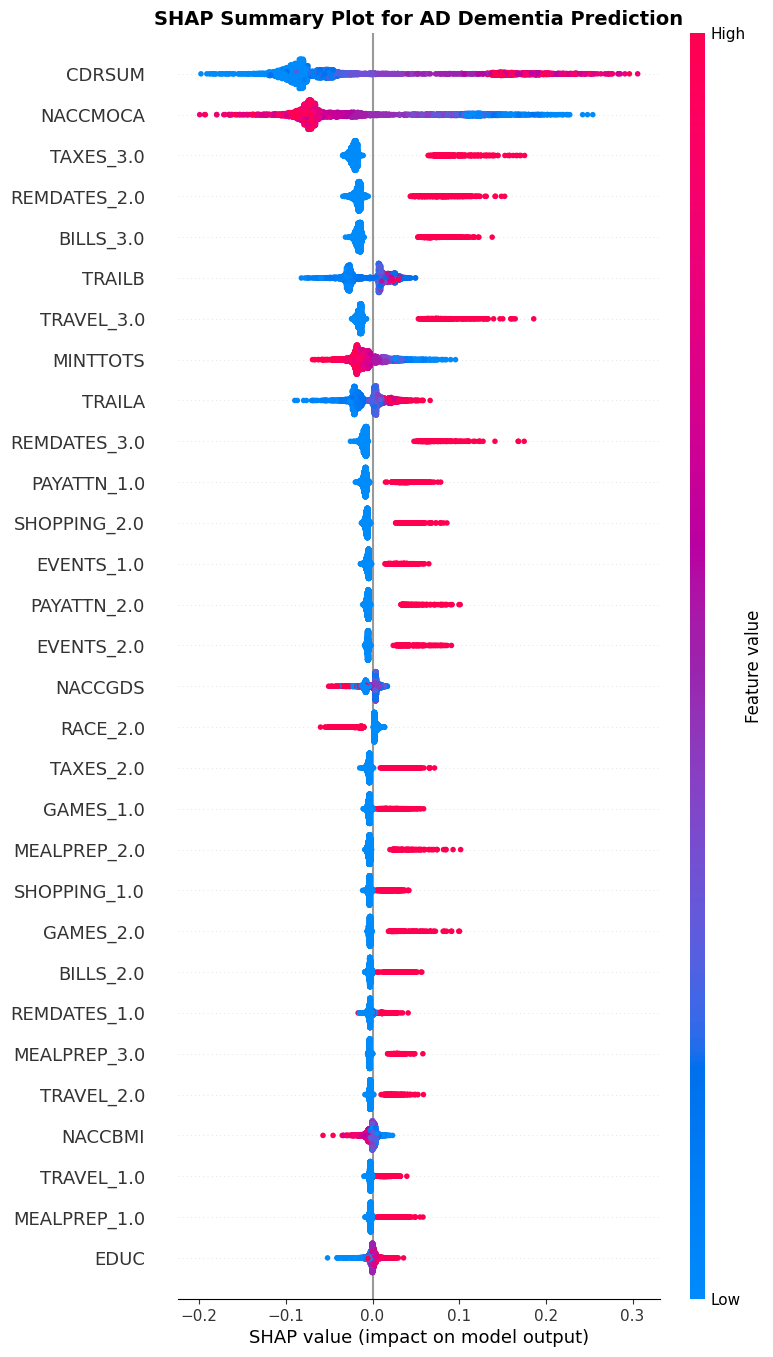

In [70]:
# shap_values- a list of arrays for multiclass(one array per class)
#Summary plot for MCI classes (show top 30)
shap.summary_plot(shap_values_MCI, X_test_scaled_df, max_display=30, show=False)
plt.title("SHAP Summary Plot for MCI Prediction", fontsize=14, fontweight='bold')
plt.show()

#Summary plot for AD dementia classes (show top 30)
shap.summary_plot(shap_values_AD, X_test_scaled_df, max_display=30, show=False)
plt.title("SHAP Summary Plot for AD Dementia Prediction", fontsize=14, fontweight='bold')
plt.show()

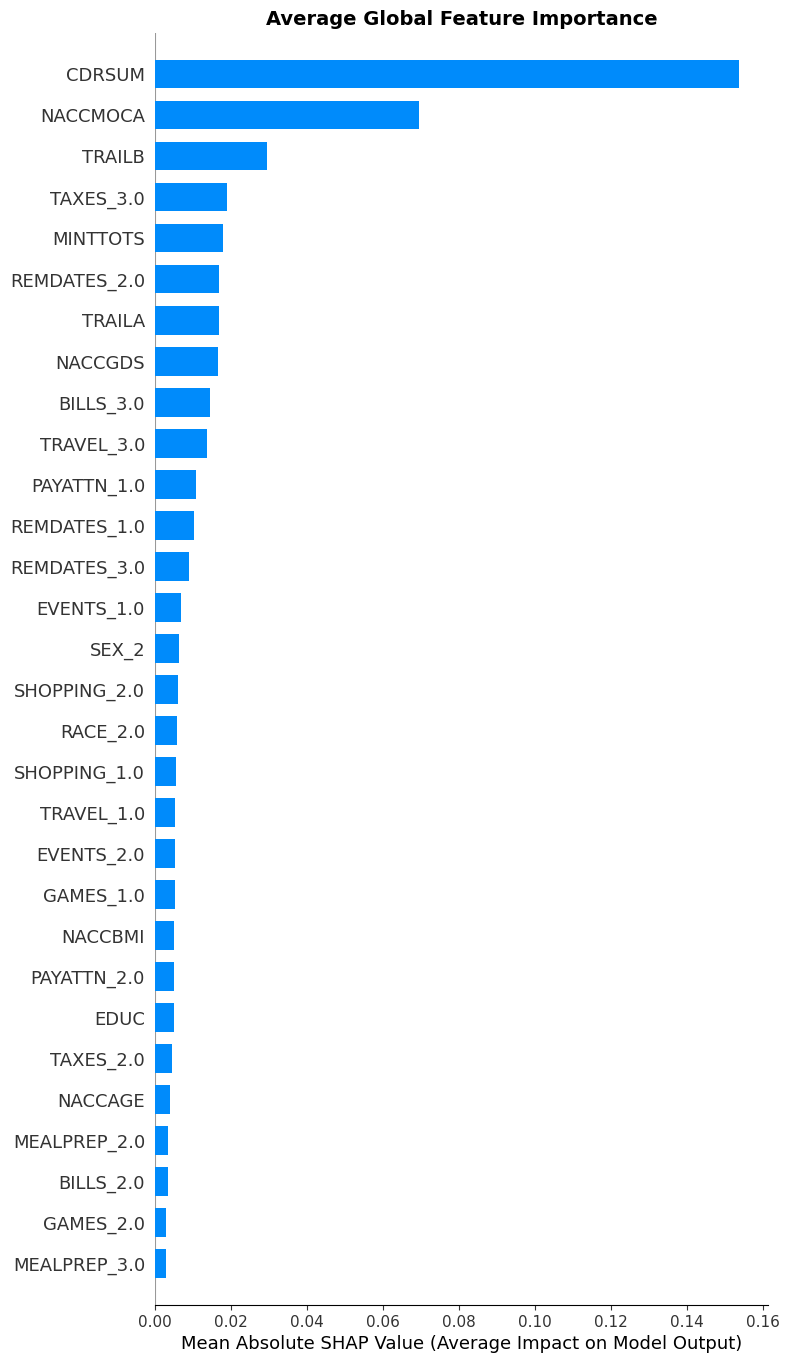

In [71]:
#Bar plot for Global feature importance
#take absolute mean (remove negative sign)
global_shap_values = np.mean(np.abs(shap_values), axis=2)

#(show top 30)
shap.summary_plot(global_shap_values, X_test_scaled_df, plot_type="bar", max_display=30, show=False)
plt.title("Average Global Feature Importance", fontsize=14, fontweight='bold')
plt.xlabel("Mean Absolute SHAP Value (Average Impact on Model Output)")
plt.show()

# 7. Save chosen RF model and other needed files for system

In [ ]:
#use joblib to save it as a file
#will be used in external validation using ADNI dataset
import joblib

#save scaler used
joblib.dump(scaler, 'minmax_scaler.pkl')
#save encoder
joblib.dump(ohe, 'onehot_encoder.pkl')
#save chosen encoded features list
joblib.dump(final_feature, 'selected_features.pkl')
#save trained model
joblib.dump(best_rf, 'best_rf_model.pkl')

#just in case, need to record the imputation values
#when doctor didnt fill value for some feature, it is needed
con_var = [v for v in con_var if v in nacc_cleaned.columns]
cat_var = [v for v in cat_var if v in nacc_cleaned.columns]
imputer_values = {
    "con_median": nacc_cleaned[con_var].median().to_dict(),
    "cat_mode": nacc_cleaned[cat_var].mode().iloc[0].to_dict()
}

joblib.dump(imputer_values, "imputer_value.pkl")


['imputer_value.pkl']